## Demonstrate Fourier series decomposition 

Use Fourier series to interpolate, differentiate suitable functions.

In [ ]:
import sys
import os
import math
import numpy as np
import scipy

import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib
%config InlineBackend.figure_format = 'retina'

import seaborn as sns

# SEABORN & MATPLOTLIBN CONFIGURATION
# seaborn styles (choose by changing index at end)
context=['paper', 'notebook', 'talk', 'poster'] [1]
palette=['deep', 'muted', 'bright', 'pastel', 'dark', 'colorblind', 'hls', 'tab10'] [2]
style=['darkgrid', 'whitegrid', 'dark', 'white', 'ticks'] [4] 

# extra customizations
# https://matplotlib.org/stable/tutorials/introductory/customizing.html
# uncomment this to get list of all rc-params: 
#print(plt.rcParams.keys())
rc={"axes.grid":"false", #"true",
    "axes.grid.which": "major",
    "grid.color":'lightgrey',
    "grid.linewidth":0.6,
    'xtick.direction':'in',
    'xtick.top':True,
    'ytick.direction':'in',
    'ytick.right':True
    }

sns.set_theme(style=style,context=context, palette=palette,
              font_scale=1, rc=rc)
print(sys.version)
print("Seaborn version {}".format(sns.__version__))

3.11.0 | packaged by conda-forge | (main, Jan 14 2023, 12:27:40) [GCC 11.3.0]
Seaborn version 0.12.2


In [1]:
import Fourier

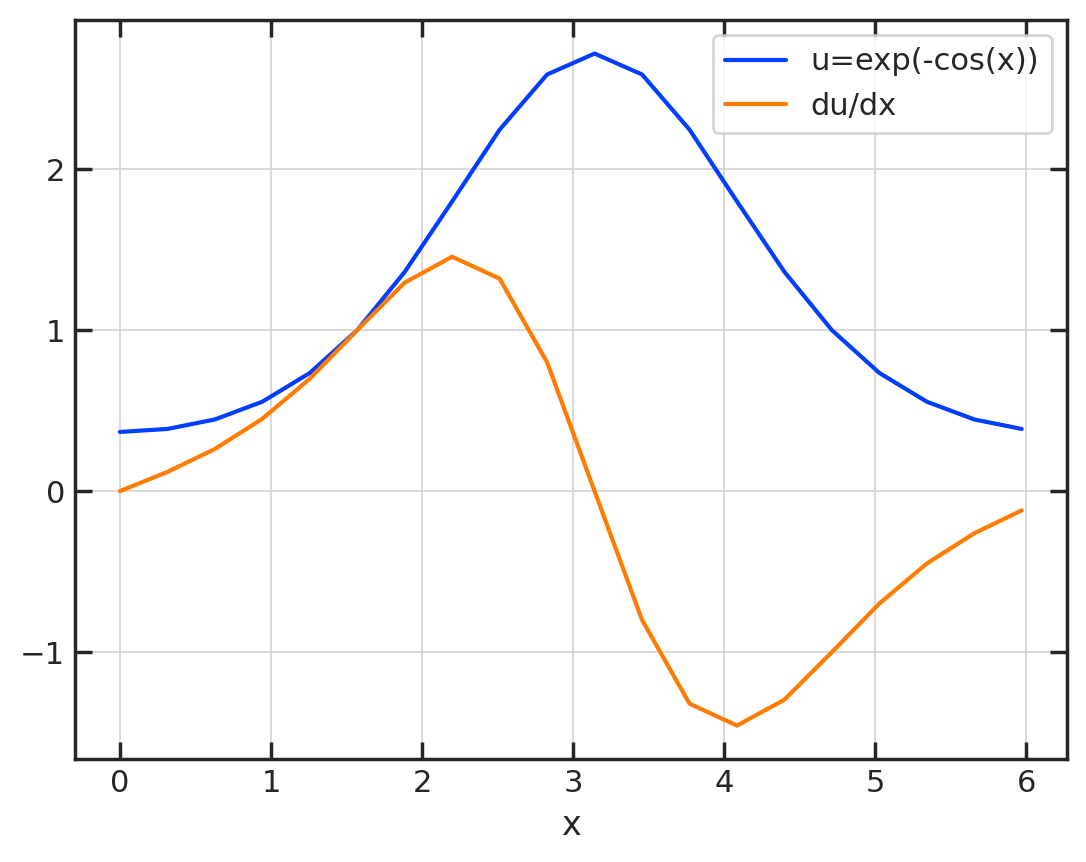

In [2]:
N = 20

x = np.linspace(0, 2 * np.pi, num=N, endpoint=False)
u = np.exp(-np.cos(x))
du = np.sin(x) * np.exp(-np.cos(x))

plt.plot(x, u, label="u=exp(-cos(x))")
plt.plot(x, du, label="du/dx")
plt.xlabel("x")
plt.grid()
plt.legend()

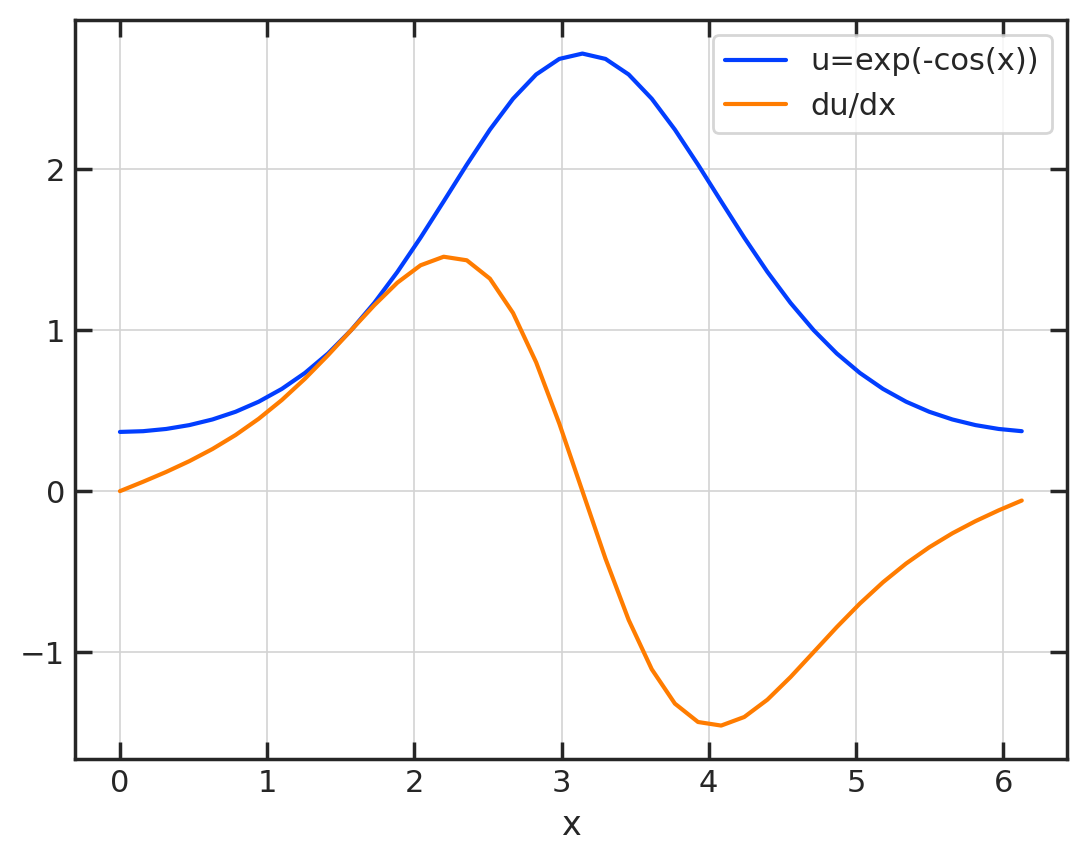

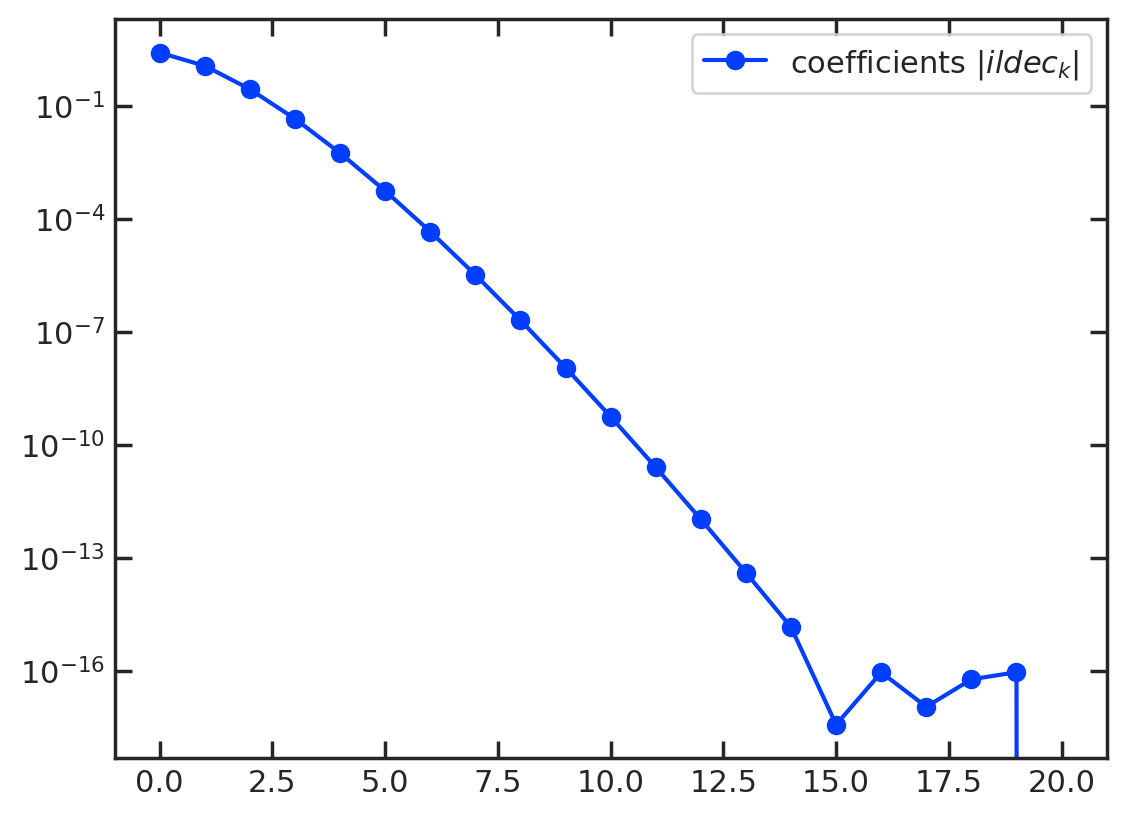

In [3]:
N = 10 + 30

x = np.linspace(0, 2 * np.pi, num=N, endpoint=False)
u = np.exp(-np.cos(x))
du = np.sin(x) * np.exp(-np.cos(x))
# u = np.cos(x)
# du = -np.sin(x)

coefs = Fourier.RealToFourier(u)

plt.plot(x, u, label="u=exp(-cos(x))")
plt.plot(x, du, label="du/dx")
plt.xlabel("x")
plt.grid()
plt.legend()

plt.figure()
plt.plot(np.abs(coefs), '-o', label="coefficients $|\tilde c_k|$")
plt.legend()
plt.yscale("log")

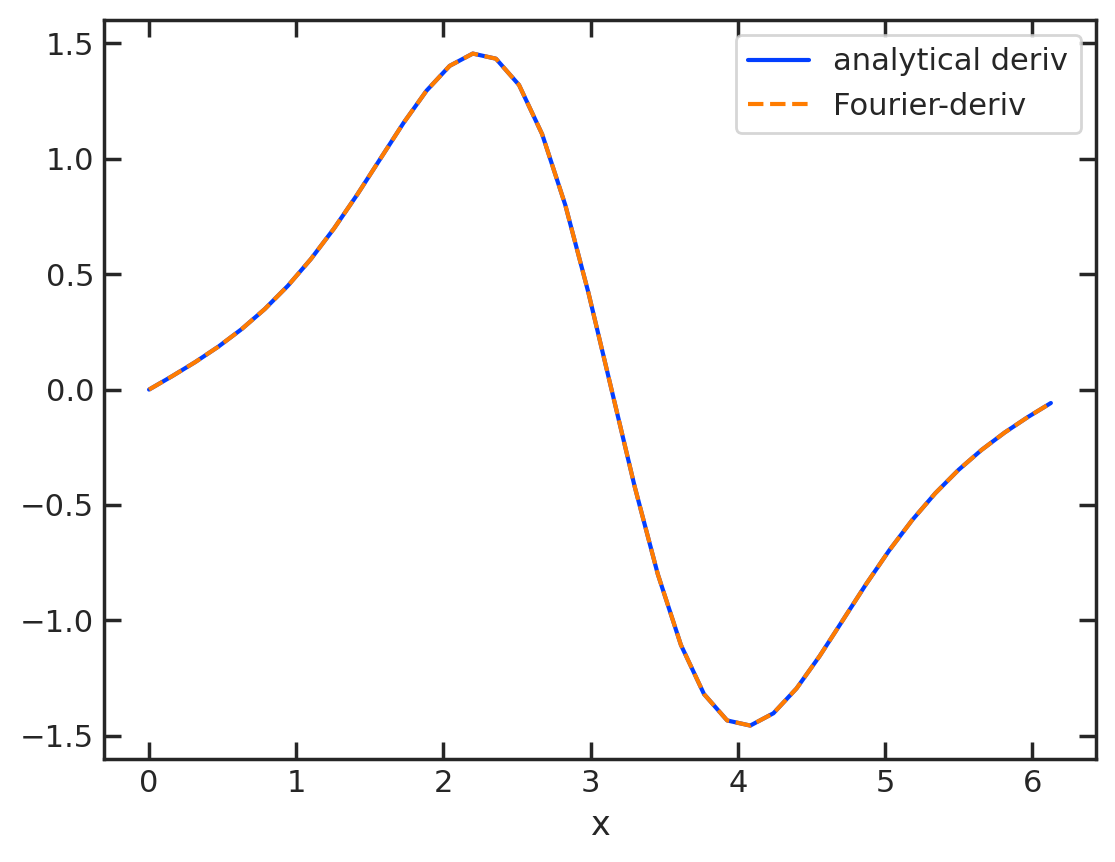

In [4]:
du_Fourier = Fourier.dudx_Fourier(u)

plt.plot(x, du, label="analytical deriv")
plt.plot(x, du_Fourier, '--', label="Fourier-deriv")
plt.xlabel("x")
plt.legend()

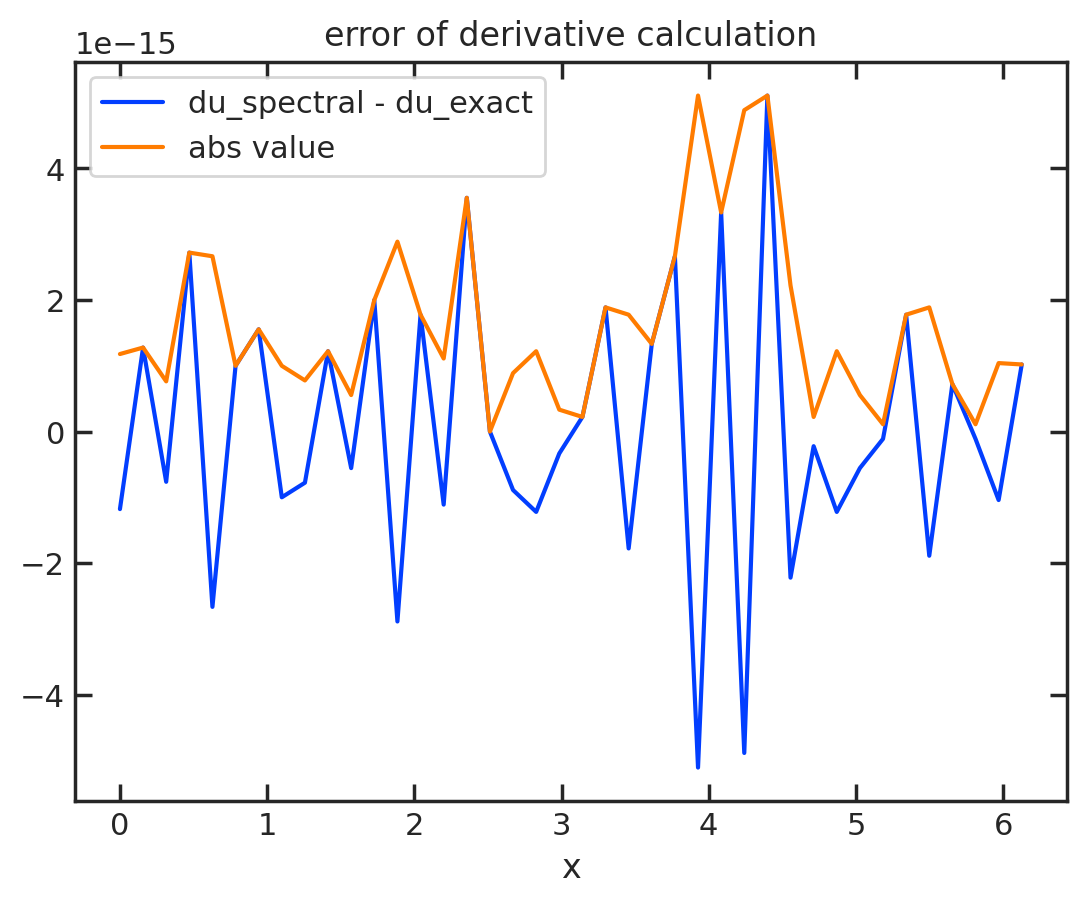

In [5]:
plt.plot(x, du_Fourier - du, label="du_spectral - du_exact")
plt.plot(x, np.abs(du_Fourier - du), label="abs value")
plt.xlabel("x")
plt.title("error of derivative calculation")
plt.legend()

Convergence of Fourier expansion

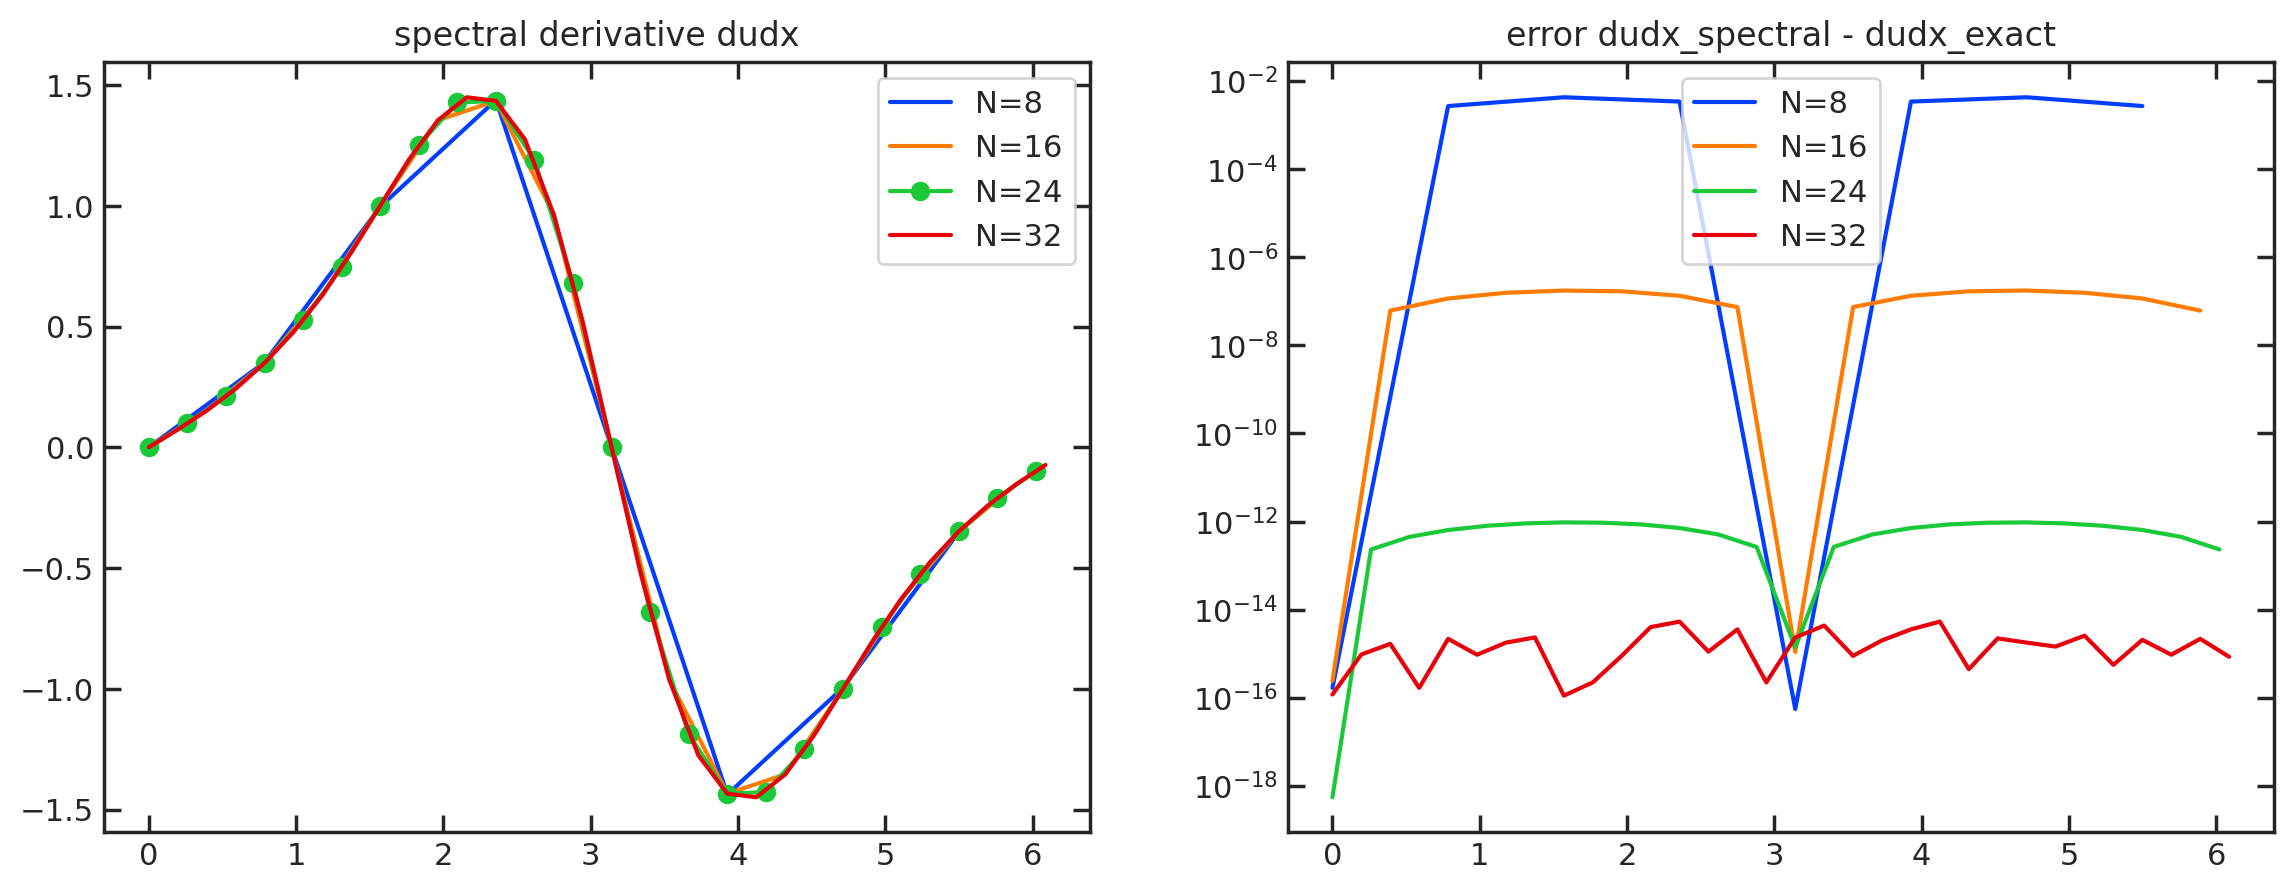

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

for N in 8, 16, 24, 32:
    x = np.linspace(0, 2 * np.pi, num=N, endpoint=False)
    u = np.exp(-np.cos(x))
    du = np.sin(x) * np.exp(-np.cos(x))
    du_spectral = Fourier.dudx_Fourier(u)
    if N == 24:
        axs[0].plot(x, du_spectral, "-o", markersize=6, label=f"N={N}")
    else:
        axs[0].plot(x, du_spectral, label=f"N={N}")

    axs[1].plot(x, np.abs(du_spectral - du), label=f"N={N}")

axs[0].set_title("spectral derivative dudx")
axs[1].set_title("error dudx_spectral - dudx_exact")
axs[0].legend()
axs[1].legend()
axs[1].set_yscale("log")

Convergence of Fourier expansion

Text(0.5, 0, 'coefficient k')

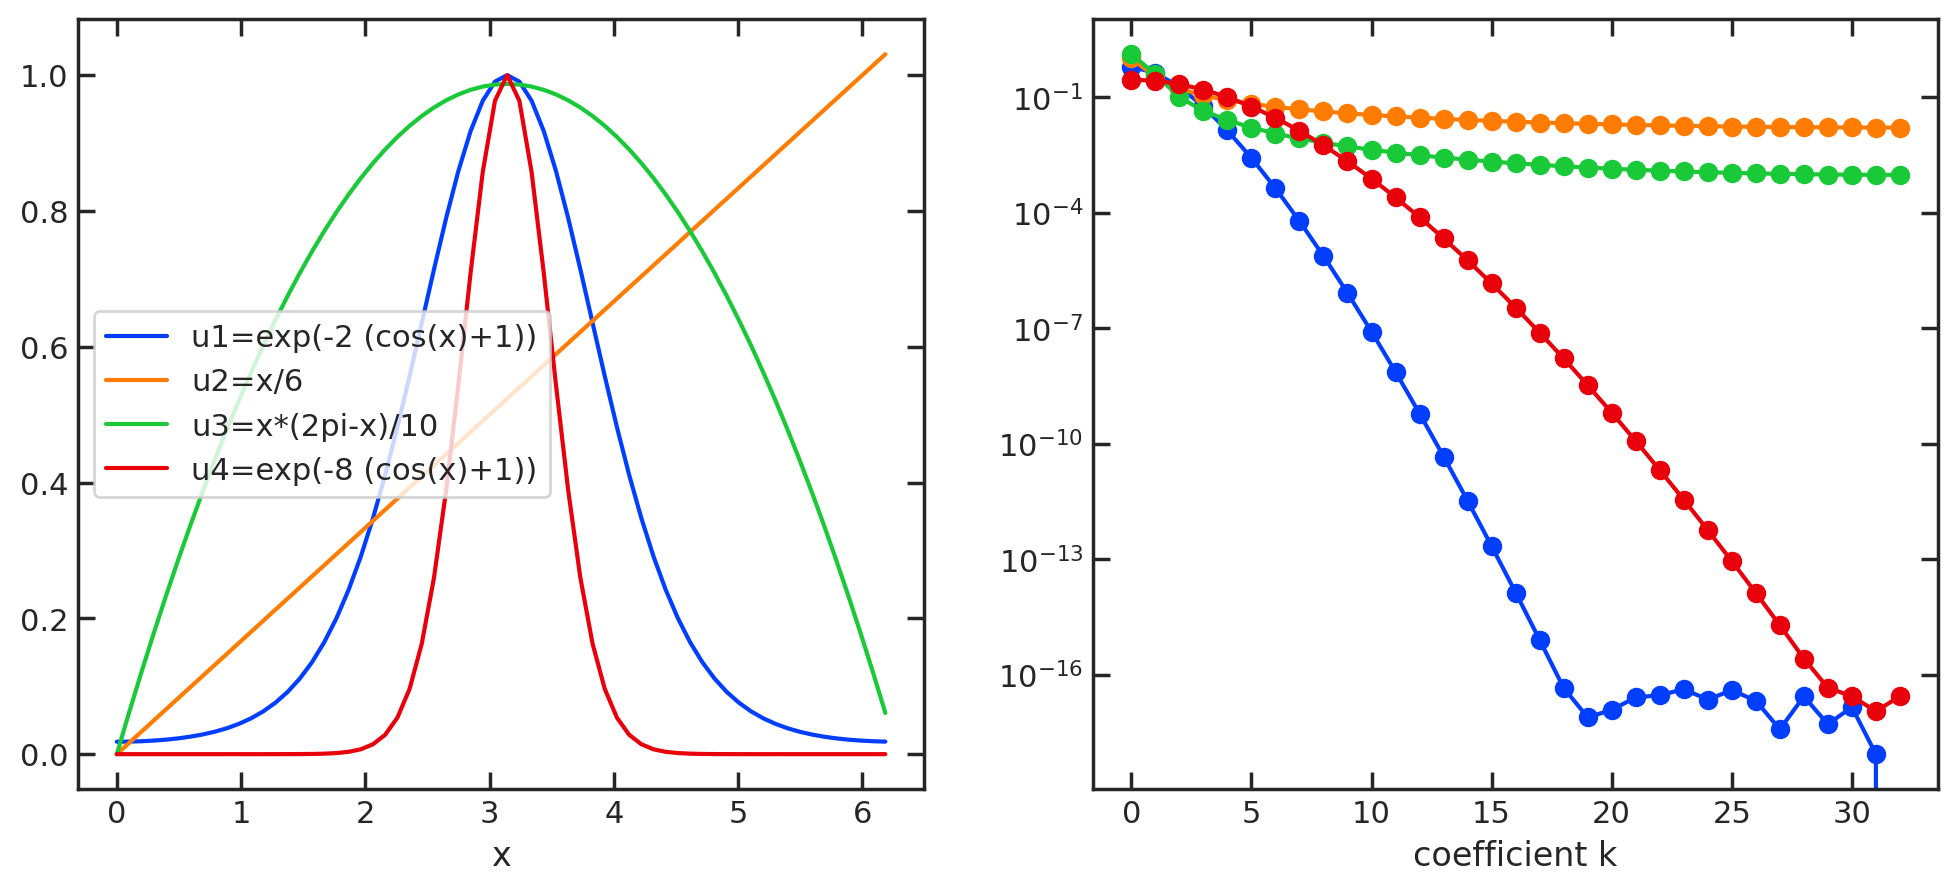

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
N = 64
x = np.linspace(0.0, 2 * np.pi, N, endpoint=False)  # no endpoint, 2pi==0


def PLOT(axs, x, u, label):
    ctilde = Fourier.RealToFourier(u)
    axs[0].plot(x, u, label=label)
    axs[1].plot(np.abs(ctilde), "-o")


# calculating & plotting the four functions
PLOT(axs, x, np.exp(-2 * (np.cos(x) + 1)), "u1=exp(-2 (cos(x)+1))")
PLOT(axs, x, x / 6, "u2=x/6")
PLOT(axs, x, x * (2 * np.pi - x) / 10, "u3=x*(2pi-x)/10")
PLOT(axs, x, np.exp(-8 * (np.cos(x) + 1)), "u4=exp(-8 (cos(x)+1))")

# cosmetics on the figure
axs[0].legend()
axs[0].set_xlabel("x")
axs[1].set_yscale("log")
axs[1].set_xlabel("coefficient k")